### Advanced Programming Assignment _8
### Name: Dejene Seboka
### ID No: GSR/6247/18

# Question 1: Genome Representation Types

- **[Linear reference genome]**  
  Represents the genome as one long, continuous sequence chosen as a standard reference.  
  - **Strengths:** Easy to use, widely adopted, efficient for alignment.  
  - **Weaknesses:** Reflects only one individual, overlooks population-level variation.  

- **[Assembly graph]**  
  Built during genome assembly to show how sequence fragments overlap.  
  - **Nodes:** Contigs or k-mers.  
  - **Edges:** Connections based on overlaps.  
  - Captures repeats and ambiguous regions that a linear reference cannot.  

- **[Variation graph]**  
  Encodes genetic differences relative to a reference sequence.  
  - **Nodes:** Sequence segments.  
  - **Edges:** Alternative alleles or structural variants.  
  - Useful for mapping reads across diverse genetic backgrounds.  

- **[Genome graph]**  
  A broad term for graph-based genome models.  
  - Can represent repeats, structural changes, and variation.  
  - Provides more flexibility than a single linear reference.  

- **[Pangenome graph]**  
  Combines multiple genomes from a species into one graph.  
  - Highlights **core regions** shared by all and **accessory regions** that differ.  
  - Enables population-scale studies and evolutionary insights.  


# Question 2: BFS and DFS in Genomic Graph Analysis

- **[Breadth-First Search (BFS)]**  
  - Traverses the graph layer by layer.  
  - Effective for locating the **shortest paths** in genome graphs.  
  - Helps reveal **connected components** and systematically explore genetic variation.  
  - Example: tracing shared haplotypes among individuals by scanning variation graphs.  

- **[Depth-First Search (DFS)]**  
  - Follows one path deeply before backtracking.  
  - Useful for **enumerating paths** and identifying motifs.  
  - Supports haplotype reconstruction by following alternative allelic routes.  
  - Example: investigating all possible assembly paths in an **assembly graph**.  
Both BFS and DFS are fundamental in genomic graph analysis. BFS excels at broad, systematic exploration and shortest path detection, while DFS is better suited for in‑depth path reconstruction and motif discovery.


# Question 3: Linear vs Graph-Based Reference Genomes

- **[Linear reference genome]**  
  - Models the genome as one continuous sequence.  
  - **Strengths:**  
    - Straightforward and widely integrated into bioinformatics workflows.  
    - Fast and efficient for read alignment and variant detection.  
  - **Weaknesses:**  
    - Represents only one chosen individual.  
    - Fails to capture structural variation, insertions, and population diversity.  

- **[Graph-based reference genome]**  
  - Represents the genome as a graph, with nodes as sequence segments and edges showing possible connections (including variants).  
  - **Strengths:**  
    - Incorporates genetic diversity across populations.  
    - Supports multiple haplotypes and structural differences.  
    - Reduces bias when mapping reads.  
  - **Weaknesses:**  
    - More computationally demanding.  
    - Requires specialized algorithms and tools.  

 
Linear references are simple but limited in scope, while graph-based references provide a richer and more accurate view of genetic diversity. Graph-based approaches are becoming increasingly important in **[pangenomics](ca://s?q=Explain_pangenomics)** and large-scale population studies.


# Question 4: De Bruijn Graph Construction (k=3)

**Reads:** ATGC, TGCA, GCAT, CATG  



### 1. [3-mers]
- ATG  
- TGC  
- GCA  
- CAT  



### 2. [2-mer nodes]
- AT  
- TG  
- GC  
- CA  



### 3. Directed Graph Edges
Each 3-mer connects its prefix to its suffix:  
- AT → TG  
- TG → GC  
- GC → CA  
- CA → AT  



### 4. [In-degree and Out-degree]
- AT: in = 1, out = 1  
- TG: in = 1, out = 1  
- GC: in = 1, out = 1  
- CA: in = 1, out = 1  



### 5. Eulerian Path or Cycle
- Since every node has equal in-degree and out-degree, the graph supports an **Eulerian cycle**.  



### 6. [Reconstructed sequence]
- Walking through the cycle gives: **ATGCATG** (cyclic sequence).  


In [1]:
from collections import defaultdict

# Input reads and k-mer length
reads = ["ATGC", "TGCA", "GCAT", "CATG"]
k = 3

# Step 1: Extract all k-mers
kmers = []
for read in reads:
    for i in range(len(read) - k + 1):
        kmers.append(read[i:i+k])
print("3-mers:", kmers)

# Step 2: Define nodes (prefixes and suffixes of k-mers)
nodes = set()
for kmer in kmers:
    nodes.add(kmer[:-1])
    nodes.add(kmer[1:])
print("Nodes:", nodes)

# Step 3: Build graph edges
edges = []
for kmer in kmers:
    edges.append((kmer[:-1], kmer[1:]))
print("Edges:", edges)

# Step 4: Compute in-degree and out-degree
in_degree = defaultdict(int)
out_degree = defaultdict(int)
for u, v in edges:
    out_degree[u] += 1
    in_degree[v] += 1

print("In-degree:", dict(in_degree))
print("Out-degree:", dict(out_degree))

# Step 5: Check if Eulerian cycle exists
is_cycle = all(in_degree[node] == out_degree[node] for node in nodes)
print("Eulerian cycle exists:", is_cycle)

# Step 6: Reconstruct sequence (simple walk through k-mers)
sequence = kmers[0]
for kmer in kmers[1:]:
    sequence += kmer[-1]
print("Reconstructed sequence:", sequence)


3-mers: ['ATG', 'TGC', 'TGC', 'GCA', 'GCA', 'CAT', 'CAT', 'ATG']
Nodes: {'AT', 'GC', 'TG', 'CA'}
Edges: [('AT', 'TG'), ('TG', 'GC'), ('TG', 'GC'), ('GC', 'CA'), ('GC', 'CA'), ('CA', 'AT'), ('CA', 'AT'), ('AT', 'TG')]
In-degree: {'TG': 2, 'GC': 2, 'CA': 2, 'AT': 2}
Out-degree: {'AT': 2, 'TG': 2, 'GC': 2, 'CA': 2}
Eulerian cycle exists: True
Reconstructed sequence: ATGCCAATTG


# Question 5: Building a Pangenome Graph

**Genomes:**  
- Genome 1: ACTGAC  
- Genome 2: ACTAAC  
- Genome 3: ACTGGAC  



### 1. [Shared sequence regions]  
- All three genomes begin with **ACT** and end with **AC**.  



### 2. [Single Nucleotide Polymorphism (SNP)]  
- At the fourth position:  
  - Genome 1 → G  
  - Genome 2 → A  
  - Genome 3 → G  
- SNP identified: **A ↔ G**.  



### 3. [Insertion]  
- Genome 3 contains an extra **G** before the final AC.  
- Insertion = **G**.  



### 4. Graph Representation  
- Start node: **ACT**.  
- Branch at position 4: either **A** or **G**.  
- If **G**, Genome 3 adds another **G** before merging back at **AC**.  
- All paths eventually rejoin at **AC**.  


### 5. [Genome paths]  
- Genome 1: ACT → G → AC  
- Genome 2: ACT → A → AC  
- Genome 3: ACT → G → G → AC  



### 6. [Branch and rejoin nodes] 
- Branch node: immediately after **ACT**.  
- Rejoin node: just before **AC**.  



### 7. [Segment classification]  
- **Core:** ACT, AC  
- **Accessory:** A, G (SNP variants)  
- **Unique:** Extra G (insertion in Genome 3)  


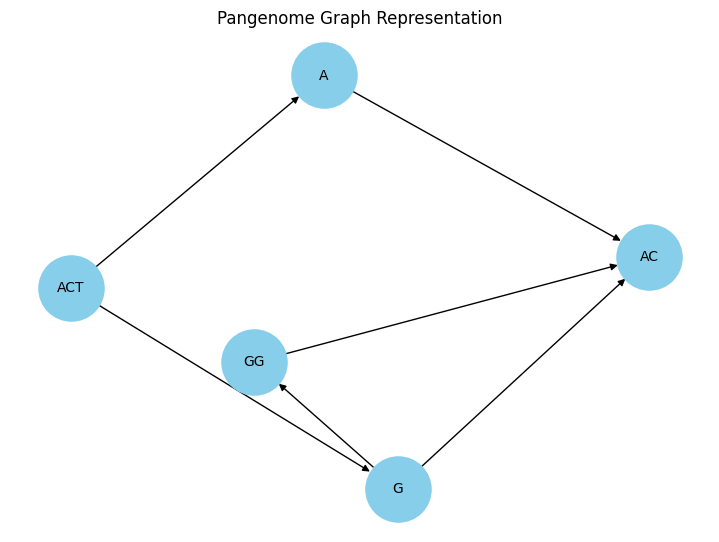

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Define edges for the three genome paths
edges = [
    ("ACT", "A"), ("A", "AC"),             # Genome 2 path
    ("ACT", "G"), ("G", "AC"),             # Genome 1 path
    ("ACT", "G"), ("G", "GG"), ("GG", "AC")  # Genome 3 with insertion
]

# Create a directed graph
graph = nx.DiGraph()
graph.add_edges_from(edges)

# Draw the graph
plt.figure(figsize=(7,5))
layout = nx.spring_layout(graph, seed=7)
nx.draw(
    graph, layout,
    with_labels=True,
    node_color="skyblue",
    node_size=2200,
    font_size=10,
    arrows=True
)
plt.title("Pangenome Graph Representation")
plt.show()


# Question 6: Graph Traversal

**Graph structure:**  
- A → B → D  
- A → C → D  
- C → E → F  



### 1. [BFS starting at A](ca://s?q=Perform_BFS_from_A)  
Breadth-First Search explores level by level.  
- Traversal order: **A, B, C, D, E, F**  



### 2. [DFS starting at A](ca://s?q=Perform_DFS_from_A)  
Depth-First Search follows one branch deeply before backtracking.  
- Traversal order: **A, B, D, C, E, F**  



### 3. [Paths from A to D](ca://s?q=List_all_paths_from_A_to_D)  
- Path 1: A → B → D  
- Path 2: A → C → D  



### 4. [Branching nodes](ca://s?q=Identify_branching_nodes)  
- **A** (splits into B and C)  
- **C** (splits into D and E)  



### 5. [Acyclic check](ca://s?q=Determine_if_graph_is_acyclic)  
- No cycles are present → Graph is **acyclic**.  


In [3]:
from collections import deque

# Graph definition
graph_structure = {
    "A": ["B", "C"],
    "B": ["D"],
    "C": ["D", "E"],
    "D": [],
    "E": ["F"],
    "F": []
}

# Breadth-First Search
def bfs_traversal(start):
    visited = set([start])
    queue = deque([start])
    order = []
    while queue:
        current = queue.popleft()
        order.append(current)
        for neighbor in graph_structure[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return order

# Depth-First Search
def dfs_traversal(start, visited=None, order=None):
    if visited is None:
        visited = set()
    if order is None:
        order = []
    visited.add(start)
    order.append(start)
    for neighbor in graph_structure[start]:
        if neighbor not in visited:
            dfs_traversal(neighbor, visited, order)
    return order

# Find all paths between two nodes
def find_paths(start, end, path=None):
    if path is None:
        path = []
    path = path + [start]
    if start == end:
        return [path]
    if start not in graph_structure:
        return []
    paths = []
    for neighbor in graph_structure[start]:
        if neighbor not in path:
            new_paths = find_paths(neighbor, end, path)
            for p in new_paths:
                paths.append(p)
    return paths

# Run the functions
print("BFS from A:", bfs_traversal("A"))
print("DFS from A:", dfs_traversal("A"))
print("Paths from A to D:", find_paths("A", "D"))


BFS from A: ['A', 'B', 'C', 'D', 'E', 'F']
DFS from A: ['A', 'B', 'D', 'C', 'E', 'F']
Paths from A to D: [['A', 'B', 'D'], ['A', 'C', 'D']]
